# 07. Reject Invalid Subscriber #2

## 07.1. Confirmation Email

### 7.1.0 Overview

Main reason we prioritize sending our newsletter subscribers a confirmation email, is because we want explicit consent for the
subscribers that we can send them newletter issues. This allows us to;
1. Shield our users from abuse (EU mandates explicit consent from the user for example)
2. We get to confirm that the email addresses they provided actually exist before trying to send them a newsletter

# 7.1.1. The Confirmation User Journey

Every time a user want to subscribe to our newsletter they fire a `POST /subscriptions` request. Our request handler will
- Add their details to our database in the `subscriptions` table, with `statux` equal to `pending_confirmation`
- generate (unique) `subscription_token`;
- store `subscription_token` in our database against their `id` in a `subscription_tokens` table;
- send an email to the new subscriber containing a link structured as `https:://<api-domain>/subscriptions/confirm?token=<subscription_token>`;
- return a `200 OK`

Once a user clicks on the link, a browser tab will open up and `GET` request will be fired to our `GET /subscription/confirm` endpoint. Our request
handler will:
- retrieve `subscription_token` from the query parameters
- retrieve the subscriber `id` associated with the `subscription_token` from the `subscriptions_token` table;
- update the subscriber status from `pending_confirmation` to active in the `subscriptions` table;
- return a `200 OK`.

<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px;">

<h4>Note:</h4>
    
There are a few other possible designs/approaches (e.g. use a JWT instead of a unique token) and we have a few edge/corner cases to handle e.g.
- What happens if they click on the link twice?
- What happends if they try to subscribe twice?

We will discuss both at the most appropriate time as we make progress with the implementation.

</div>

The implementation strategy
1. Write a module to send an email
2. adapt the logic of our existing `POST /subscriptions` request handler to match new specifications
3. write a `GET /subscriptions/confirm` request handler from scratch.

## 07.2. EmailClient, Our Email Delivery Component

### 7.2.1. How to Send An Email

#### 7.2.1.0. Overview

How do we _actually_ send an email?

How does it work?

We have to look into **SMTP**
> **S**imple **M**ail **T**ransfer **P**rotocol
>
> Its been around since the early days of the internet - the first RFC dates back to 1982.
>

SMTP does for emails what HTTP does for web pages:
> it is an application-level protocol that ensures that different implementations of email servers and clients can understand each other and
> exchange messages.

We will not be building our own private email server, it will take too long and we wouldn't gain much from the effort. We will be leveraging a
third-party service.

Do we need to talk SMTP to these third party services?

Not necessarily.

SMTP is a specialised protocol. Learning a new protocol takes time and we are bound to make mistakes along the way - that is why most providers
provide two interfaces: SMTP and REST API

If we were familiar with the email protocol, or we needed some non-conventional configuration, we would use the SMTP interface. Otherwise we will
get up and running much faster and more reliably using a REST API

#### 7.2.1.1. Choosing an Email API

For our implementation we will work with 
- [Postmark](https://account.postmarkapp.com/servers) - for following along with the book (need a work email with private domain)
- [MailJet](https://app.mailjet.com/onboarding) - a Postmark alternative (Works with public domains [gmail, yahoo] for now)

<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px;">


<h4>Note:</h4>
    
We had a challenge setting up **DKIM** and **Return-Path** verification for our [hai-hub.com](hai-hub.com) domain because we were adding the Postmark DNS records
to squarespace which where we have registered our domain but our DNS records are managed else where (_Netlify_). Adding the DNS records on netlify resolved 
the issue.

</div>

#### 7.2.1.2. The Email Client Interface

There are usually two approaches when it comes to a new piece of functionality
1. Bottom-Up - starting from the implementation details and slowly working our way up
2. Top-Down - designing the interface first and then figuring out how the implementation is going to work (to an extent).

In this case, we will go for the second route.

What kind of interface do we want for our email client?

We'd like to have some kind of `send_email` method. At the moment we just need to send a single email out at a time - we will deal
with the complexity of sending emails in batches when we start working on newsletter issues.

What arguments should `send_email` accept?

We will definitely need;
- recipient email address,
- the subject line,
- email contents
    - We'll ask for both HTML and plain versions of the email content
- sender email address? We'll assume that all emails sent by an instance of the client are coming from the same address, therefore we
  do not need it as an argument of `send_email`, it will be one of the arguments in the constructor of the client itself.

We will also expect `send_email` to be an asynchronous function, given that we will be performing I/O to talk to a remote server.

Stiching everything together, we have something that looks more or less like this:

```Rust
//! src/email_client.rs

use crate::domain::SubscriberEmail;

pub struct EmailClient {
    sender: SubscriberEmail;
}

impl EmailClient {
    pub async fn send_email(
        &self,
        _recipient: SubscriberEmail,
        _subject: &str,
        _html_content: &str,
        _text_content: &str,
    ) -> Result<(), String>
    {
        todo!("NOT YET IMPLEMENTED")
        
    }
}


//! src/lib.rs

pub mod configuration;
pub mod domain;
// New entry!
pub mod email_client;
pub mod routes;
pub mod startup;
pub mod telemetry;
```

There is an unresolved question - the return type. We sketched a `Result<(), String>` which is a way to spell _"I'll think about error handling later"_.

### 7.2.2. How To Write A REST Client Using `reqwest`

#### 7.2.2.0. Overview

To talk with a REST API we need a HTTP client.

We will go with the most popular option on crates.io: [reqwest](https://crates.io/crates/reqwest)

What to say about [reqwest](https://crates.io/crates/reqwest)
- It has been exhaustively battle-tested (~450 million downloads as of this writing)
- It offers a primarily asynchronous interface, with the option to enable a synchronous one via the blocking feature flag.
- It relies on tokio as its asynchronous executor, matching what we are already using due to `actix-web`;
- It does not depend on any system library if we only choose `rustls` to back the TLS implementation (`rustls` feature flag)
  making it extremely portable

And we are already using `reqwest` in our intergration tests. Let's lift it from a development dependency to a runtime
dependency.

```toml
#! Cargo.toml
#  [...]

[dependencies]
# We need the `json` feature flag to serialize/deserialize JSON payloads
reqwest = {version = "0.13", features = ["json", "rustls"]}

[dev-dependencies]
# Remove `reqwest`'s entry from this list
# [...]
```

#### 7.2.2.1. `reqwest::Client`

The main type we will be dealing with when working with `reqwest` is `reqwest::Client` - it exposes all the methods we need to
perform requests against a REST API.

We will use `Client::new` to get a new client instance although we could have also used `Client::builder` if we needed to tune
the default configuration.

We add two fields to `EmailClient`:
- `http_client`, to store a `Client` instance
- `base_url`, to store the URL of the API we'll be making requests to

```Rust
//! src/email_client.rs

use crate::domain::SubscriberEmail;

pub struct EmailClient {
    http_client: reqwest::Client,
    base_url: String,
    sender: SubscriberEmail,
}

impl EmailClient {
    pub fn new(
        base_url: String, 
        sender: SubscriberEmail,
    ) -> Self
    {
        Self {
            http_client: Client::new(),
            base_url,
            sender
        }
    }

    // [...]
}
```

#### 7.2.2.2. Connection Pooling

Before executing a HTTP request against an API hosted on a remote server we need to establish a connection.

It turns out that connecting is a fairly expensive operation, even more so if using HTTPS:
> creating a brand-new connection every time we need to fire off a request can impact the performace of our application and
> might lead to a problem known as _**socket exhaustion**_ under load.

To mitigate the issue, most HTTP clients offer _connection pooling_:
> after the first request to a remote server has been completed, they will keep the connection open (for a certain amout of
> time) and re-use it if we need to fire off another request to the same server, therefore avoiding the need to re-establish
> a connection from scratch.

`reqwest` is not different- every time a `Client` instance is created `reqwest` initialises a connection pool under the hood.

To leverage this connection pool we need to **re-use the same Client** across multiple requests.

> It is worth noting that `Client::clone` does not create a new connection pool - we just clone a _pointer_ to the underlying
> pool

#### 7.2.2.3. How to Reuse The Same `reqwest::Client` In `actix-web`

To re-use the same HTTP client acros multiple requests in `actix-web` we need to store a copy of it in the application context -
we will then be able to retrieve a reference to `Client` in our request handlers using an extractor (e.g.
`actix_web::web::Data`)

To pool this off we have 2 options
- derive the `Clone` trait for `EmailClient`, build an instance of it once and then pass a cline to `app_data` everytime we need
 to build an App:
  
     >  ```Rust
     > //! src/email.rs
     > #[derive(Clone)]
     > pub struct EmailClient {
     >    http_client: reqwest::Client,
     >    base_url: String,
     >    sender_email: SubscriberEmail,
     > }
     > // [...]
     > ``` 
       
     > ```Rust 
     > //! src/startup.rs
     > use crate::email_client::EmailClient
     > // [...]
     > 
     > pub fn run(
     >     listener: TcpListener,    
     >     db_pool: PgPool,    
     >     email_client: EmailClient,    
     > ) -> Result<Server, std::io::Error> {
     >    let db_pool = Data::new(db_pool);
     >    let server = HttpServer::new( move || {
     >        App::new()
     >            .wrap(TracingLogger::default()) 
     >            .route("/health_check", web::get().to(health_check))          
     >            .route("/subscriptions", web::post().to(subscribe))          
     >            .app_data(db_pool.clone())
     >            .app_data(email_client.clone())
     >   }) 
     >   .listener(listener)?
     >   .run();
     >
     >   Ok(server) 
     > }
     > 
     > ```
 - wrap `EmailClient` in `actix_web::web::Data` (an `Arc` pointer) and pass a pointer to `app_data` every time we need to build
   an App - like we are doing with `PgPool`;
    > ```Rust 
     > //! src/startup.rs
     > use crate::email_client::EmailClient
     > // [...]
     > 
     > pub fn run(
     >     listener: TcpListener,    
     >     db_pool: PgPool,    
     >     email_client: EmailClient, // New param   
     > ) -> Result<Server, std::io::Error> {
     >    let db_pool = Data::new(db_pool);
     >    let email_client = Data::new(email_client);
     >    let server = HttpServer::new( move || {
     >        App::new()
     >            .wrap(TracingLogger::default()) 
     >            .route("/health_check", web::get().to(health_check))          
     >            .route("/subscriptions", web::post().to(subscribe))          
     >            .app_data(db_pool.clone())
     >            .app_data(email_client.clone())
     >   }) 
     >   .listener(listener)?
     >   .run();
     >
     >   Ok(server) 
     > }
     > 
     > ```

Which way is best?

If `EmailClient` were just a wraper around a `Client` instance, the first option would be preferable - we avoid wrapping the 
connection pool twice with `Arc`.

This is not the case though: `EmailClient` has two data fields attached
- `base_url`
- `sender`

The first implementation (`Clone`) allocates new memory to hold a copy of that data every time an App instance is created, while
the second shares it among all App instances.

Beware though, we are creating an App instance for each thread - the cose of a string allocation (or a pointer clone) is 
negligible when looking at the bigger picture.

We are going through the decision-making process here as an exercise to understand the tradeoffs - we might have to make a 
similar call in the future where the cost of the two options is remarkably different.

#### 7.2.2.4. Configuring Our `EmailClient`.

Running `cargo check`, will get us the error below

```bash
error[E0061]: this function takes 3 arguments but 2 arguments were supplied
--> src/main.rs:24:5
|
24 | run(listener, connection_pool)?.await?;
| ^^^ -------- --------------- supplied 2 arguments
| |
| expected 3 arguments
error: aborting due to previous error
```

Looking at our `src/main.rs` it is clear that we have not added the `email_client` argument to the `run` call below

```Rust
//! src/main.rs
// [...]

#[tokio::main]
async fn main() -> Result<(), std::io::Error> {
    // [...]
    run(listener, connecton_pool)?.await?;
    Ok(())
}
```

We are building the dependencies of our application (address & db) using the values specified in the configuration we retrieved
via `get_configuration`.

To build an `EmailClient` instance we need the base URL of the API we want to fire requests to and the sender email address 
<span>&mdash;</span> let's add them to our `Settings` struct:

```Rust
//! src/config.rs
// [...]

use crate::domain::SubscribeEmail;

#[derive(serde::Deserialize)]
pub struct Settings {
    pub db: DBSettings,
    pub app: AppSettings,
    pub email_client_settings: EmailClientSettings, // New field
}

#[derive(serde::Deserialze)]
pub struct EmailClientSettings {
    pub base_url: String,
    pub sender_email: String,
}

impl EmailClientSettings {
    pub fn sender(&self) -> Result<SubscriberEmail, String> {
        SubscriberEmail::parse(self.sender_email.clone())
    }
}

// [...]
```

We need to set values for the in our configuratoin files

```yaml
#! configuration/base.yaml
app:
    # [...]
db:
    # [...]
email_client_settings:
    base_url: "localhost"
    sender_email: "test@gmail.com"
```

```yaml
#! configuration/production.yaml
app:
    # [...]
db:
    # [...]
email_client_settings:
    # Value retrieved from Postmark's API documentation
    base_url: "https:://api.postmarkapp.com"
    # Use the single sender email ww authorised on Postmark!
    sender_email: "test@gmail.com"
```

We can now build an `EmailClient` instance in `main` and pass it to the `run` function

```Rust
//! src/main.rs
// [...]
use zero2prod::email_client::EmailClient;

#[tokio::main]
async fn main() -> Result<(), std::io::Error> {
    // [...]
    let configuration = get_configuration().expect("Failed to read configuration");
    let connection_pool = PgPoolOptions::new()
        .connect_lazy_with(configuration.db.connect_options());

    // Build an `EmailClient` using `configuration`
    let sender_email = configuration.email_client_settings.sender()
        .expect("Invalid sender email address.");

    let email_client = EmailClient::new(
        configuration.email_client_settings.base_url,
        sender_email,
    );

    let address = format!(
        "{}:{}",
        configuration.app.host, configuration.app.port
    );

    let listener = TcpListener::bind(address)?;
   // Adding new argument `email_client`  to `run`
    run(listener, connecton_pool)?.await?;
    Ok(())
}
```

`cargo check` should now pass, although there are a few warnings about unused variables, which we'll get to.

`cargo check --all-targets` returns an error similar to the one we've just addressed for the `run` function in our intergration
tests.

```bash
error[E0061]: this function takes 3 arguments but 2 arguments were supplied
--> tests/health_check.rs:36:18
|
36 | let server = run(listener, connection_pool.clone())
| ^^^ -------- ----------------------- supplied 2 arguments
| |
| expected 3 arguments
error: aborting due to previous error
```

We do have some code duplication that we need to address but let's patch it quickly for now for our code to compile.

```Rust
//! tests/health_check.rs

// [...]
use zero2prod::email_client::EmailClient;
// [...]

async fn spawn_app() -> TestApp {
    // [...]
    let mut configuration = get_configuration()
        .expect("Failed to read configuration");
    configuration.db.db_name = Uuid::now_v7().to_string();
    let conection_pool = configure_db(&configuration.database).await;

    // Bulld a new email client
    let sender_email = configuration.email_client_settings.sender()
        .expect("Invalid email address");
    let email_client = EmailClient::new(
        configuration.email_client_settings.base_url,
        sender_email,
    );

    // Pass hte new client to `run`
    let server = run(listener, connection_pool.clone(), email_client)
        .expect("Failed to bind address");

    let _ = tokio::spawn(server);

    TestApp {
        address,
        db_pool: connection_pool,
    }
}
```

`cargo test` should succeed now.

#### 7.2.2.5. Re-use: Axum implementation

For our axum implementation. The biggest difference is on how we re-use our `EmailClient` and `PgPool` instances. 

We make use of an `AppState` struct that wraps both `PgPool` and `EmailClient` as follows.
```Rust
//! src/startup.rs
// [...]

#[derive(Clone)]
pub struct AppState {
    pub db_pool: PgPool
    pub email_client: Arc<EmailClient>,
}

pub async run(
    listener: TcpListener,
    db_pool: PgPool,
    email_client: EmailClient,
) -> Result<(), std::io::Error> {
    // [...]
    let state = AppState {
        db_pool,
        email_client: Arc::new(email_client),
    }
    let app = Router::new()
                .route("/health_check", get(health_check))
                .route("/subscriptions", post(subscribe))
                .layer(tracing_layer)
                .with_state(state); // Passing state
}
```

Note how we instatiate `email_client` with `Arc::new()`. This allows us to re-use `email_client` without cloning in a thread safe manner.

The rest of the implementation looks similar to the Actix implementation with one exception. The `subscribe` function. Since now we are using `AppState` we need to update the `subscribe` function route to take in a state instead of the `db_pool` only as shown below.

```Rust
//! src/routes/subscriptions.rs
// [...]
#[tracing::instrument(
    name = "Adding a new subscriber",
    skip(state, form), // Updated to use `state` instead of `db_pool
    fields (
        subscriber_email = &form.email,
        subscriber_username = &form.username,
    )
)]
pub async fn subscribe(
    State(state): State<AppState>, // Updated from `State(db_pool): State<PgPool>`
    Form(form): Form<FormData>,
) -> impl IntoResponse {
    // [...]
    
    // We update `insert_subscriber` argument  as well
    match insert_subscriber(&state.db_pool, &new_subscriber).await {
        // [...]
    }
}
```

### 7.2.3. How to Test A REST Client Using `reqwest`

#### 7.2.3.0. Overview

Staying true to T.D.D. its time to write a test!

We could start from our integration tests: change the ones for `POST /subscriptions` to make sure that the endpoint conforms to our new requirements.

It would take us a long time to turn them green through: apart from sending an email, we need to add logic to generate a unique token and store it.

We start smaller: we will just test our `EmailClient` component in isolation.<br>
It will boost our confidence that it behaves as expected when tested as a _unit_, reducing the number of issues we might encounter when integrating it
into the larger confirmation email flow.<br>
It will also give us a chance to see if the interface we landed on is ergonomic and easy to test.

What should we actually test though?<br>
The main purpose of our `EmailClient::send_email` is to perform a HTTP call:<br>
- How would we know it happened?
- How do we check that the body and the headers were populated as we expected?

We need to _intercept_ that HTTP request <span>&mdash;</span> time to spin up a mock server!

#### 7.2.3.1. HTTP Mocking With `wiremock`

We add a test module at the bottom of `src/email_client.rs`. We do not know enough about Postmark to make assertions about what we should
see in the outgoing HTTP request.<br>
Nonetheless, it is reasonable to expect a request to be fired to the server at `EmailClient::base_url`. We add `wiremock` to our development
dependencies with `cargo add --dev wiremock`.

Using `wiremock`, we can write a test `send_email_fires_a_request_to_base_url` as follows:

```Rust
//! src/email_client.rs
// [..]

#[cfg(test)]
mod tests {
    use crate::domain::SubscriberEmail;
    use crate::email_client::EmailClient;
    use fake::faker::internet::en::SafeEmail;
    use fake::faker::lorem::en::{Paragraph, Sentence};
    use fake::{Fake, Faker};
    use wiremock::matchers::any;
    use wiremock::{Mock, MockServer, ResponseTemplate};

    #[tokio::test]
    async fn send_email_fires_a_request_to_base_url() {
        // Arange
        let mock_server = MockServer::start().await;
        let sender = SubscriberEmail::parse(SafeEmail().fake()).unwrap();
        let email_client = EmailClient::new(mock_server.uri(), sender);

        Mock::given(any())
            .respond_with(ResponseTemplate::new(200))
            .expect(1)
            .mount(&mock_server)
            .await;

        let subscriber_email = SubscriberEmail::parse(SafeEmail().fake()).unwrap();
        let subject: String = Sentence(1..2).fake();
        let content: String = Paragraph(1..10).fake(); 

        // Act
        let _ = email_client
            .send_email(subscriber_email, &subject, &content, &content)
            .await;

        // Assert
    }
    
}
```

Let's break down what's happening, step by step.

#### 7.2.3.2. `wiremock::MockServer`

```Rust
let mock_server = MockServer::start().await;
```

`wiremock::MockServer` is a full-blown HTTP server.<br>
`MockServer::start` asks the operating system for a random available port and spings up the server on a back-ground thread, ready to listen for incoming
requests.

How do we point our email client to our mock server?<br>
We can retreive the address of the mock server using the `MockServer::uri` method; we can then pass it 
as the `base_url` to `EmailClient::new` as in the line

```Rust
let email_client = EmailClient::new(mock_server.uri(), sender);
```

#### 7.2.3.3. `wiremock::Mock`

Out of the box, `wiremock::MockServer` returns `404 Not Found` to all incoming requests.<br>
We can instruct the mock server to behave differently by mounting a `Mock`.

```Rust
Mock::give(any())
    .respond_with(ResponseTemplate::new(200))
    .expect(1)
    .mount(&mock_server)
    .await;
```

When `wiremock::MockServer` receives a request, it iterates over all the mounted mocks to check if the request _matches_ their conditions.<br>
The matching conditions for a mock are specified using `Mock::given`.

We are passing `any()` to `Mock::Given` which, according to `wiremock`'s documentation.

<div style="background: #313B51; color: white; padding: 15px; border-radius: 15px; border: 2px solid white;">

Match all incoming requests, regardless of their method, path, headers or body. You can use it to verify that a request has been fired towards the server, without
making any other assertion about it
    
</div>

Basically, it always matches, regardless of the request - which is want we want here.

When an incoming request matches the condition of a mounted mock, `wiremock::MockServer` returns a response following what was specified in `respond_with`. We passed
`ResponseTemplate::new(200)` - a `200 Ok` response without a body.

A `wiremock::Mock` becomes effective only after it has been mounted on a `wiremock::Mockserver` - that's what our call to `Mock::mount` is about.

#### 7.2.3.4. The Intent Of A Test Should Be Clear

We then have the actual invocation of `EmailClient::send_email`:

```Rust
let subscriber_email = SubscriberEmail::parse(SafeEmail().fake()).unwrap();
let subject: String = Sentence(1..3).fake();
let contents: String = Paragraph(1..10).fake();

// Act
let _ = email_client.send_email(subscriber_email, &subject, &contents, &contents).await;
```

Notice that we are leaning heavily on `fake` here: we are generating random data for all the inputs to `send_email`.<br>
We could have just hard-coded a bunch of values, why did we choose to go all the way and make them random?

A reader, skimming the test code should be able to identify easily the property that we are trying to test. Using random data conveys a specific message:
> _do not pay attention to these inputs, their values do not influence the outcome of the test, that's why they are random!_

Hard-coded values instead, should always give us pause: does it matter that `subscriber_email` is set to `"marco@gmail.com"`? Should the test pass if I set it
to another value? In a test like ours, the answer is obvious. In a more intricate setup, it often isn't.

#### 7.2.3.5. Mock expectations

The end of the test looks a bit cryptic: there is an `// Assert` comment... but no assertion afterwards. Let's go back to our `Mock` setup line:
```Rust
Mock::given(any())
    .respond_with(ResponseTemplate::new(200))
    .expect(1)
    .mount(&mock_server)
    .await;
```


What does `.expect(1)` do?<br>
It sents an _expectation_ on our mock; we are telling the mock server that during this test it should receive _exactly_ one request that matches the
conditions set by this mock.<br>
We could also use ranges for our expectations - e.g. `expect(1..)` if we want to see _at least_ one request, `expect(1..=3)` if we expect at least one
request but no more than three, etc.

Expectations are verified when `MockServer` goes out of scope - at the end of our test function. Before shutting down, `MockServer` will iterate over 
all the mounted mocks and check if their expectations have been verified. If the verification step fails, it will trigger a panic and fail the test.

In our case running `cargo -test` results in the error below.

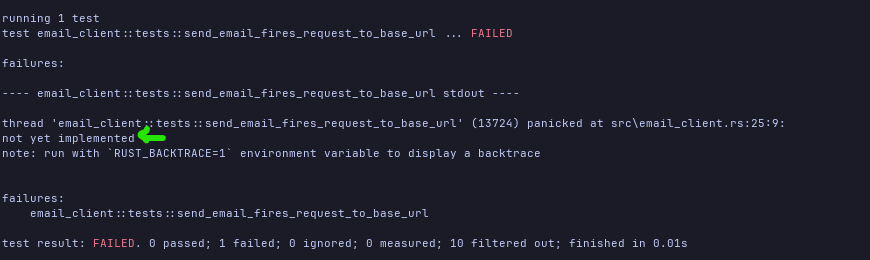

Our `todo!()` placeholder in `send_email`'s body causes our test to fail.

Let's replace it with a dummy `Ok`

```Rust
//! src/email_client.rs
// [...]

impl EmailClient {
    // [...]

    pub async fn send_email(
        recipient_email: SubscriberEmail,
        subject: &st,
        html_content: &str,
        txt_content: &str, 
    ) -> Result<(), String> {
        // No matter the input.
        Ok(())
    }
}
// [...]
```

Running the test again, we'll get to see `wiremock` in action

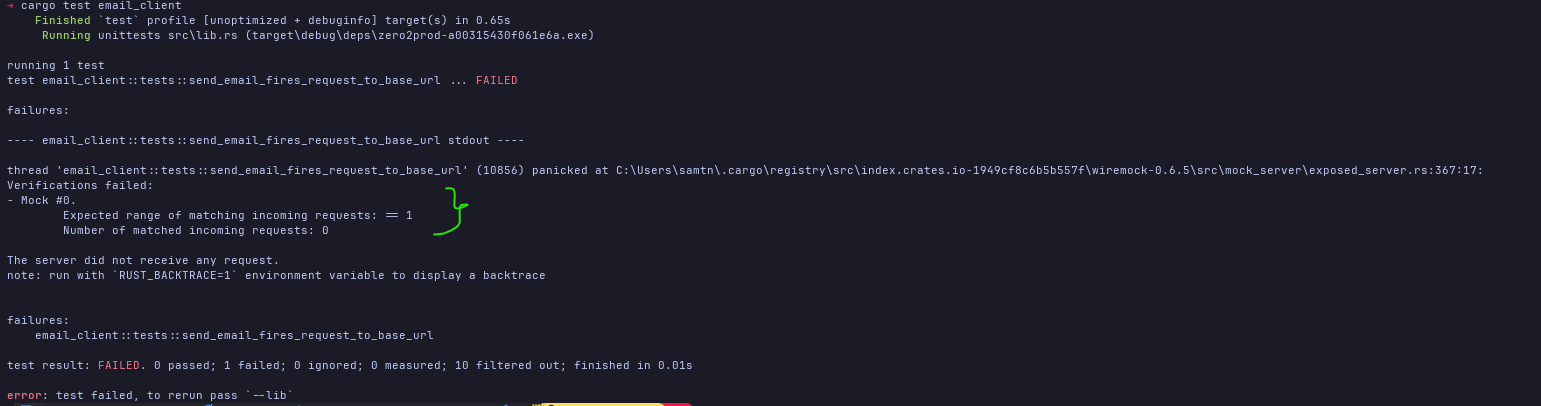
The server expected one request, but it received none - therefore the test failed.

We now need to flesh out `EmailClient::send_email` properly.

### 7.2.4. First Sketch Of `EmailClient::send_email`

#### 7.2.4.0. Overview

Let's take a look at Postmark's API documentation for ["Send a single email"](https://postmarkapp.com/developer/api/email-api)

The example request with `curl` looks like this:
```bash
curl "https://api.postmarkapp.com/email" \
    -X POST \
    - H "Accept: application/json" \
    - H "Content-Type: application/json" \
    - H "X-Postmark-Server-Token: server token" \
    - d '{
        "From": "sender@example.com",
        "To": "sender@example.com",
        "Subject": "Postmark test",
        "TextBody": "Hello dear Postmark user",
        "HtmlBody": "<html><body><strong>Hello</strong> dear Postmark user.</body></html>",
        "MessageStream": "outbound",
    }'
```

Let's break it down - to send an email we need:
- a `POST` request to the `/email` endpoint;
- a `JSON` body, with fields that map closely to the arguments of `send_email`. We need to be careful with fields names, they must be pascal cased.
- an authorization header, `X-Postmark-Server-Token`, with a value set to a secret token that we can retrieve from their portal.


If the request succeeds, we get a response like this back:
```bash
HTTP/1.1 200 OK
Content-Type: application/json

[
  {
    "ErrorCode": 0,
    "Message": "OK",
    "MessageID": "b7bc2f4a-e38e-4336-af7d-e6c392c2f817",
    "SubmittedAt": "2010-11-26T12:01:05.1794748-05:00",
    "To": "receiver1@example.com"
  },
  {
    "ErrorCode": 406,
    "Message": "You tried to send to a recipient that has been marked as inactive. Found inactive addresses: example@example.com. Inactive recipients are ones that have generated a hard bounce, a spam complaint, or a manual suppression. "
  }
]
```

We have enough to implement the happy path.

#### 7.2.4.1. `reqwest::Client::post`

`reqwest::Client` exposes a `post` method - it takes the URL we want to call with a `POST` request as argument and it returns a `RequestBuilder`.

`RequestBuilder` gives us a fluent API to build out the rest of the request we want to send, piece by piece.

```Rust
//! src/email_client.rs
// [...]

impl EmailClient {
    // [...]
    pub async fn send_email(
        &self,
        recipient_email: &str,
        subject: &str,
        html_content: &str,
        txt_conten: &str,
    ) {
        // We can do better using `reqwest::Url::join` if we change
        // `base_url`'s type from `String` to `reqwest::Url`.
        // We'll do on for the axum implementaiton
        let req_url = format!("{}/email", self.base_url);
        let req_builder = self.http_client.post(&req_url);
        Ok(())
    }
}
```

#### 7.2.4.2. JSON body

We can encode the request body schema as a struct:

```Rust
//! src/email_client.rs
// [...]

impl EmailClient {
    // [...]
    pub async fn send_email(
        &self,
        recipient_email: &str,
        subject: &str,
        html_content: &str,
        txt_conten: &str,
    ) {
        let req_url = format!("{}/email", self.base_url);
        let req_body = SendEmailRequest {
            from: self.sender_email.as_ref().to_owned(),
            to: recipient_email.as_ref().to_owned(),
            subject: subject.to_owned(),
            html_body: html_content.to_owned(),
            txt_body: txt_body.to_owned(),
        };
        let req_builder = self.http_client
            .post(&req_url)
            .json(&req_body);
            
        Ok(())
    }
}

#[derive(serde::Serialize)]
struct SendEmailRequest {
    from: String,
    to: String,
    subject: String,
    html_body: String,
    txt_body: String,
}
```

Updating the `src/email_client.rs` with the above should compile.<br>
The `json` call we chain to `post` goes a bit further than simple serialization: it will also set the `Content-Type` header to `application/json` matching
what we saw in the example.

#### 7.2.4.3. Authorization Token

Next we need to add an authorization header, `X-Postmark-Server-Token`, to the request. Just like the `sender_email` we need to store the token value as a
field in `EmailClient`.

We update `EmailClient::new` and `EmailClientSettings` as follows:

```Rust
//! src/email_client.rs
use secrecy::Secret;
// [...]
pub struct EmailClient {
    // [...]
    authorization_token: SecretString,
}

impl EmailClient {
    pub fn new (
        // [...]
        authorization_token: SecretString,
    ) -> Self {
        Self {
            // [...]

            authorization_token,
        }
    }
}

//! src/config.rs
// [...]

#[derive(serde::Deserialize)]
pub struct EmailClientSettings {
    // [...]
    pub authorization_token: SecretString
}
```

We then need to update our unit test, `main.rs` and integration test `health_check.rs` appropriately, as well as our `configuration/base.yaml`


```Rust
//! src/email_client.rs
// [...]
#[cfg(test)]
mod tests {
    // [...]
    #[tokio::test]
    fn send_email_fires_request_to_base_url() {
        //[...]
        let authorization_token = SecretString::new(Faker.fake());
        let email_client = EmailClient::new(
            mock_server.uri(),
            sender_email,
            authorization_token,
        )
    }
}

//! src/main.rs
// [...]

#[tokio::main]
async fn main() -> Result<(), std::io::Error> {
    // [...]
    let email_client = EmailClient::new(
        config.email_client.base_url,
        sender_email,
        config.email_client.authorization_token,
    );
    
    // [...]
}

//! tests/health_check.rs
// [...]


#[tokio::main]
async fn spawn_app() -> TestApp {
    // [...]
    let email_client = EmailClient::new(
        config.email_client.base_url,
        sender_email,
        config.email_client.authorization_token,
    );
    // [...]
}

```

```yaml
! configuration/base.yml
# [...]
email_client:
base_url: "localhost"
sender_email: "test@gmail.com"
# New value!
# We are only setting the development value,
# we'll deal with the production token outside of version control
# (given that it's a sensitive secret!)
authorization_token: "my-secret-token"
```

We can now use the authorization token in `send_email`:

```Rust
//! src/email_client.rs
use secrecy::{ExposeSecret, Secret};
// [...]

impl EmailClient {
    // [...]

    pub async fn send_email(
        // [...]
    ) {
        // [...]
        let req_builder = self.http_client
            .post(&req_url)
            .header(
                "X-Postmark-Server-Token",
                self.authorization_token.expose_secret()
            )
            .json(&req_body);
        Ok(())
    }
}


```

This should compile

#### 7.2.4.4. Executing The Request

Now that we have all the ingredients, we only need to fire the request now using the `send` method.

```Rust
//! src/email_client.rs
// [...]

impl EmailClient {
    // [...]

    pub async fn send_email(
        // [...]
    ) -> Result <(), String>
    {
        // [...]
        let req_builder = self.http_client
            .post(&req_url)
            .header(
                "X-Postmark-Server-Token",
                self.authorization_token.expose_secret()
            )
            .json(&req_body);
            .send() // firing the request.
            .await?;
        Ok(())
    }
}
```

`send` is asynchronous, therefore we need to `await` the future it returns.<br>
`send` is also a _fallibale operation_ - e.g. we might fail to establish a connection to the server. We'd like to return an error if `send` fails - that's why we use
the `?` operator.

The compiler is not happy though

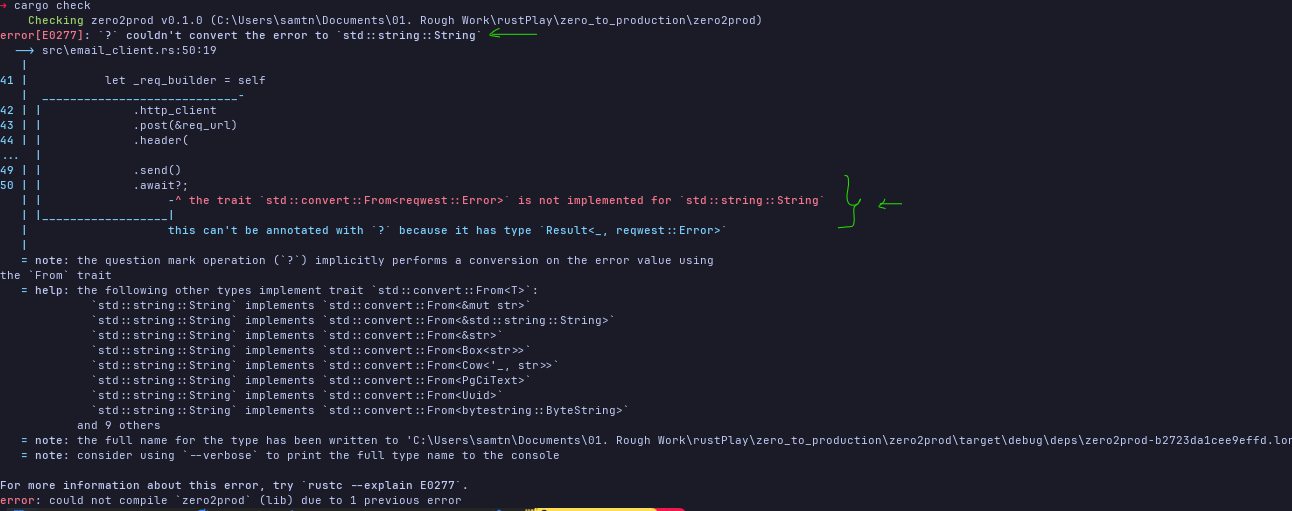

The error variant returned by `send` is of type `reqwest::Error`, while our `send_email` uses`String` as the error type. The compiler has looked for a conversion
(an implementation of the `From` trait), but it could not find any - therefore it errors out.

Because `String` as an error variant was mostly a placeholder - we change the `send_email`'s signature to return `Result<(), reqwest::Error>`.


```Rust
//! src/email_client.rs
// [...]

impl EmailClient {
    // [...]

    pub async fn send_email(
        // [...]
    ) -> Result <(), reqwest::Error>
    {
        // [...]
    }
}
```

The error should be gone now & the tests should pass too! Congrats

### 7.2.5. Tightening Our Happy Path Test

#### 7.2.5.0. Overview

Looking at our "happy path" test, we eased ourselves into the world of `wiremock` by starting with something very basic <span>&mdash;</span>.
we are just asserting that the mock server gets called once.

```Rust
//! src/email_client.rs
// [...]

#[cfg(test)]
mod tests {

    use fake::{
        Fake, Faker, ResponseTemplate,
        faker::{
            internet::en::SafeEmail,
            lorem::en::{Sentence, Paragraph},
        }
        matchers::any,
    };
    use secrecy::SecretString;
    use wiremock::{MockServer, Mock};

    use crate::{
        domain::SubscriberEmail,
        email_client::EmailClient,
    };

    #[tokio::test]
    async fn send_email_fires_request_to_base_url() {
        
        // Arrange
        let mock_server = MockServer::start().await;
        let sender_email = SubscriberEmail::parse(SafeEmail().fake()).unwrap();
        let authorization_token = SecretString::from(Faker.fake::<String>())
        let email_client = EmailClient::new(
            mock_server.uri(),
            sender_email,
            authorization_token,
        );

        Mock::give(any())
            .respond_with(ResponseTemplate::new(200))
            .expect(1) // < Expecting just 1 request, and any request (GET, POST, etc) "thus happy path" 
            .mount(&mock_server)
            .await;

        let recipient_email = SubscriberEmail::parse(SafeEmail().fake()).unwrap();
        let subject_line = Sentence(1..3).fake();
        let content = Paragraph(1..10).fake();
        
        // Act
        let _ = email_client.send_email(
            recipient_email,
            &subject_line,
            &content,
            &content
        ).await;

        // Assert
        // Mock expectations are checked on drop
    }
    
}
```

Let's beef it up to check that the outgoing request looks indeed like we expect it to.

#### 7.2.5.0.1. Headers, Path And Method

`any` is not the only matcher offered by `wiremock` out of the box: There are a handful available in `wiremock`'s `matcher` module.

We can use `header_exists` to verify that the `X-Postmark-Server-Token` is set on the request to the server. We can also chain multiple matches together using
the `and` method.<br>
Let's add `header` to check that the `Content-Type` is set to the correct value, `path` to assert on the endpoint being called and `method` to verify the HTTP
verb.

```Rust
//! src/email_client.rs
// [...]

#[cfg(test)]
mod tests {
    // [...]
    use wiremock::matchers::{header, header_exists, path, method};

    #[tokio::test]
    async fn send_email_fires_request_to_base_url() {
        // [...]

        Mock::given(header_exists("X-Postmark-Server-Token"))
            .and(header("Content-Type", "application/json"))
            .and(path("/email"))
            .and(method("POST"))
            .respond_with(ResponseTemplate::new(200))
            .expect(1)
            .mount(&mock_server)
            .await;

        // [...]
    }
}
```

Tests should still pass

#### 7.2.5.0.2. Body

What about the request body.

We could probably use `body_json` match _exactly_ the request body.<br>
We probably do not need to go as far as that <span>&mdash;</span> it would probably be enough to check that the body is valid JSON and it contains
the set of fields names shown in Postmark's example.

There is not out-of-box matcher that suits our needs <span>&mdash;</span> we need to implement our own.
> We could use `body_json_schema`, but it only validates the schema is enforce but not valid JSON for the values.

`wiremock` exposes a `Match` trait - everything that implements it can be used as a matcher in `given` and `and`.

Let's stub it out:

```Rust
//! src/email.rs
// [...]

#[cfg(test)]
mod tests {
    // [...]
    wiremock::{
        Mock,
        MockServer,
        Match, // Trait we use to stub out custom Matcher
        Request,
        ResponseTemplate 
    }

    struct SendEmailBodyMatcher;

    impl Match for SendBodyMatcher {
        fn matches(&self, request: &Request) -> bool {
            // differs from todo!() macro slightly in that todo! is temporary
            // todo!() -> "not YET implemented" i.e temporary
            // unimplemented!() -> "not implemented" i.e more long-term
            unimplemented!() // Just to expose us reader this macro
        }
    }

    
}
```

We get the incoming request as input, `request` (note its of type `wiremock::Request`), and we need to return a boolean value as output
- `true`, if the mock matched,
- `false` otherwise

We need to deserialize the request body as JSON, <span>&mdash;</span> let's add `serde-json` to the list of our development dependencies with
`cargo add serde_json`.<br>
We can now write `matches` implementation

```Rust
//! src/email_client.rs
// [...]

#[cfg(test)]
mod tests {
    // [...]

    struct SendEmailBodyMatcher;

    impl Match for SendEmailBodyMatcher {
        fn matcher(&self, request: &Request) -> bool {
            // Try to parse the body as a JSON value
            let result: Result<serde_json::Value, _> = serde_json::from_slice(&request.body);
            if let Ok(body) = result {
                // Check that all the mandatory fields are populated
                // without inspecting the field values
                body.get("From").is_some()
                    &body.get("To").is_some()
                    &body.get("Suject").is_some()
                    &body.get("HtmlBody").is_some()
                    &body.get("TextBody").is_some()
            } else {
                // If parsing failed, do not match the request
                false
            }
        }
    }

    #[test]
    fn test_send_email_fires_request_to_base_url() {
        // [...]
        Mock.given(header_exists("X-Postmark-Server-Token"))
            .and(header("Content-Type", "application/json"))
            .and(path("/eamil"))
            .and(method("POST"))
            // Using our custom matcher!
            .and(SendEmailBodyMatcher)
            .respond_with(ResponseTemplate::new(200))
            .expect(1)
            .mount(&mock_server)
            .await;
            
    }
}
```

It compiles!<br>
But out tests are failing now...

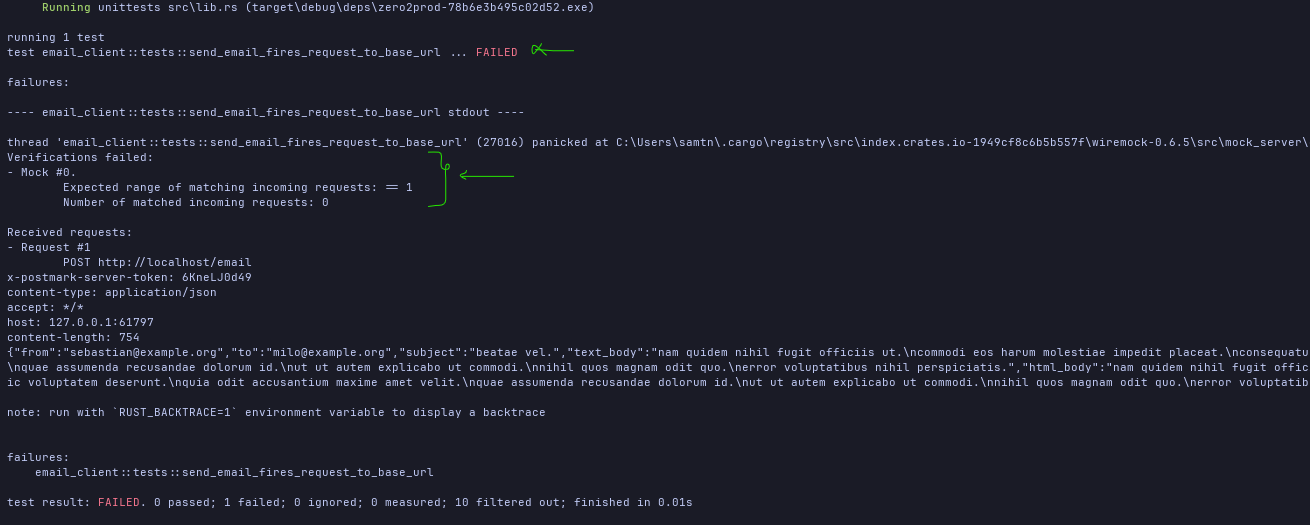

Why is that?<br>
Let's add a `dbg` statement to our matcher to inspect the incoming request:


```Rust
//! src/email_client.rs
// [...]

#[cfg(test)]
mod tests {
    // [...]

    struct SendEmailBodyMatcher;

    impl Match for SendEmailBodyMatcher {
        fn matches(&self, request: &Request) -> bool {
            // [...]
            if let Ok(body) = result {
                dbg!(&body)
                // [...]
            } else {
                false
            }
        }
    }

    #[test]
    fn test_send_email_fires_request_to_base_url() {
        // [...]
        Mock.given(header_exists("X-Postmark-Server-Token"))
            .and(header("Content-Type", "application/json"))
            .and(path("/eamil"))
            .and(method("POST"))
            // Using our custom matcher!
            .and(SendEmailBodyMatcher)
            .respond_with(ResponseTemplate::new(200))
            .expect(1)
            .mount(&mock_server)
            .await;
            
    }
}
```

Running the test again with `cargo test send_email`, we'll get something like this

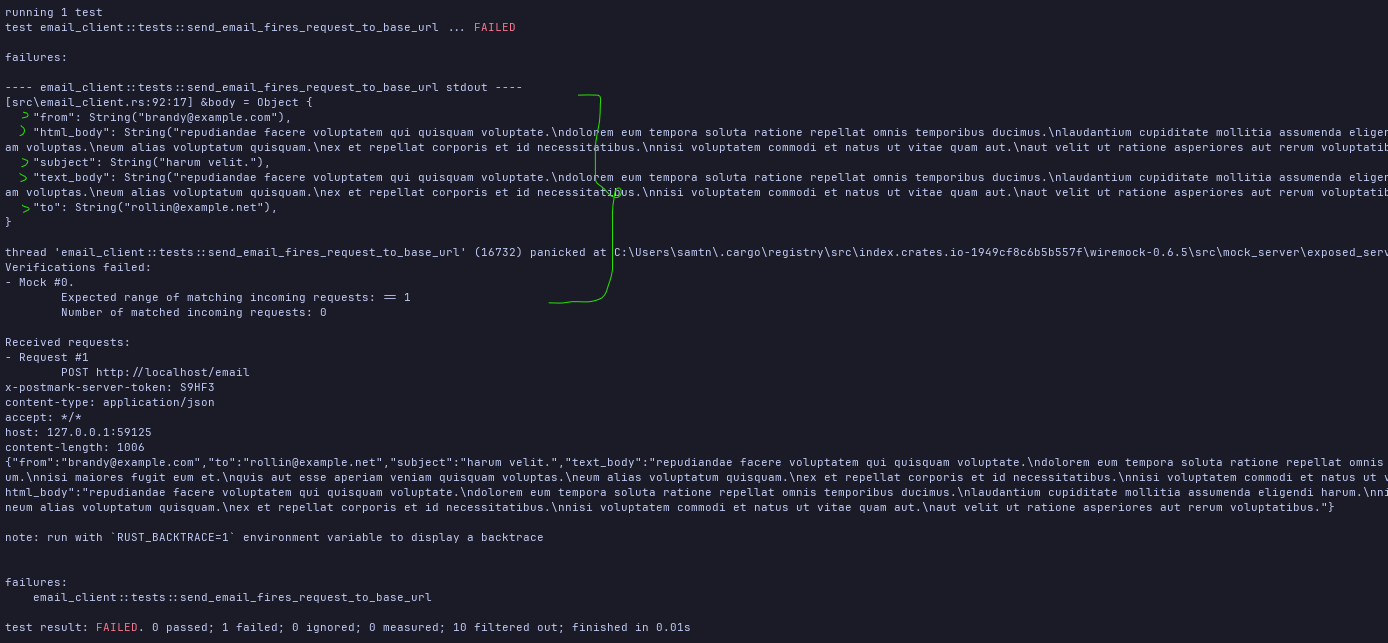

It seems we forgot about the casing requirement <span>&mdash;</span> field names must be pascal cased!
We can fix it easily by adding an annotation on `SendEmailRequestBody`

```Rust
//! src/email_client.rs
// [...]

#[derive(serder::Serialize)]
#[serde(rename_all = "PascalCase")]
struct SendEmailRequestBody {
    from: String,
    to: String,
    subject: String,
    html_body: String,
    text_body: String,
}
```

The test should pass now.<br>
Before we move on, let's rename the test to `send_email_sends_expected_request` <span>&mdash;</span> it captures better the test's purpose at this point

#### 7.2.5.1. Refactoring: Avoid Unnecessary Memory Allocations

We focused on getting `send_email` to work <span>&mdash;</span> now we can look at it again to see if there's any room for improvement.

Let's zoom on the request body:
```Rust
//! src/email_client.rs
// [...]


impl EmailClient {
    // [...]
    pub async fn send_email(
        // [...]
    ) {
        // [...]
        let req_body = SendEmailRequest {
            from: self.sender_email.as_ref().to_owned(),
            to: recipient_email.as_ref().to_owned(),
            subject: subject.to_owned(),
            html_body: html_content.to_owned(),
            txt_body: txt_body.to_owned(),
        };
        // [...]
    }
}


#[derive(serder::Serialize)]
#[serde(rename_all = "PascalCase")]
struct SendEmailRequestBody {
    from: String,
    to: String,
    subject: String,
    html_body: String,
    text_body: String,
}
```

For each field we are allocating a bunch of new memory to store a cloned `String` <span>&mdash;</span> it is wasteful. It would be more efficient to
reference the existing data without performing any additional allocation.<br>
We can pull it off by restructuring `SendEmailRequestBody`: 
> instead of `String` we have to use a string slice (`&str`) as type for all fields.

A string slice is just a pointer to a memory buffer owned by somebody else. To store a reference in a struct we need to add a lifetime parameter: It
keeps track of how long those references are valid for <span>&mdash;</ipan> it's the compiler's job to make sure that references do not stay around
longer than the memory buffer they point to!

```Rust
//! src/email_client.rs
// [...]


impl EmailClient {
    // [...]
    pub async fn send_email(
        // [...]
    ) {
        // [...]
        // No more `.to_owned`
        let req_body = SendEmailRequest {
            from: self.sender_email.as_ref(),
            to: recipient_email.as_ref(),
            subject: subject,
            html_body: html_content,
            txt_body: txt_body,
        };
        // [...]
    }
}


#[derive(serder::Serialize)]
#[serde(rename_all = "PascalCase")]
// Lifetime parameters always start with an apostrophe, `'`
struct SendEmailRequestBody<'a> {
    from: &'a str,
    to: &'a str,
    subject: &'a str,
    html_body: &'a str,
    text_body: &'a str,
}
```

That's it, quick and painless <span>&mdash;</span> `serde` does all the heavy lifting for us and we are left with more performant code!

### 7.2.6. Dealing With Failures

#### 7.2.6.0. Overview

We have a good grip on the happy path <span>&mdash;</span> what happends instead if things don't go as expected?

We'll look at 2 scenarios:
- non-success status codes (e.g. `4xx`, `5xx`, etc);
- slow responses

#### 7.2.6.1. Error Status Codes

Our current happy path test is only making assertions on the side-effect performed by `send_email` <span>&mdash;</span> we are not actually inspecting the
value it returns!<br>
Let's make sre that it is an `Ok(())` if the server returns `200 OK`.

#### 7.2.6.2. Timeouts

#### 7.2.6.3. Refactoring Helpers

#### 7.2.6.4. Refactoring: Fail Fast

## 7.3. Skeleton And Principles For A Maintainable Test Suite

## 7.4. Refocus

## 7.5. Zero Downtime Deployment

## 7.6. Database Migrations

## 7.7. Sending A Confirmation Email

## 7.8. Database Transactions

## 7.9. Summary